In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import os, glob, json
from pathlib import Path
import numpy as np
import jax
from jax import value_and_grad, jit, vmap, grad, random
import jax.numpy as jnp
import flax.linen as nn
from flax import serialization
import matplotlib.pyplot as plt
import optax

from action_angle_networks.sk_models import MyActionAngleNetwork
from action_angle_networks.simulation import harmonic_motion_simulation as hsim
from functools import partial

%config InlineBackend.figure_format = 'retina'


In [5]:
from dataclasses import dataclass
from typing import Any, Callable, Sequence, Optional, List, Tuple, Dict
@dataclass
class HarmonicParams:
    n: int
    m: np.ndarray         # (n,) masses per oscillator
    k_wall: float         # wall spring constant
    k_pair: float         # pairwise coupling spring constant
    A_modes: np.ndarray   # (n,) amplitudes per normal mode
    phi_modes: np.ndarray # (n,) phases per normal mode (radians)

def sample_harmonic_params(
    n: int,
    m_range: Tuple[float, float] = (1.0, 5.0),
    k_wall: float = 0.01,
    k_pair: float = 0.005,
    A_range: Tuple[float, float] = (1.0, 3.0),
    seed: Optional[int] = 0,
) -> HarmonicParams:
    rng = np.random.default_rng(seed)
    m = rng.uniform(*m_range, size=(n,)).astype(np.float64)
    # Normal-mode amplitudes/phases
    A_modes = rng.uniform(*A_range, size=(n,)).astype(np.float64)
    phi_modes = rng.uniform(0.0, 2*np.pi, size=(n,)).astype(np.float64)
    return HarmonicParams(
        n=n, m=m, k_wall=float(k_wall), k_pair=float(k_pair),
        A_modes=A_modes, phi_modes=phi_modes
    )

def harmonic_hamiltonian(q: np.ndarray, p: np.ndarray, params: HarmonicParams) -> float:
    """
    q, p: (B, n)
    """
    n = params.n
    V_wall = 0.5 * params.k_wall * np.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * params.k_pair * ((np.sum(q, axis=1)**2 - np.sum(q**2, axis=1))/2.0)  # (B,)
    V = V_wall + V_pair # (B,)
    T = 0.5 * np.sum((p**2) / params.m, axis=1)  # (B,)
    H = T + V
    return float(H)


def harmonic_hamiltonian_jax(q: jnp.ndarray, p: jnp.ndarray, params: HarmonicParams) -> jnp.ndarray:
    """
    q, p: (B, n)  -> returns (B,)
    NOTE: m を jnp に変換して計算
    """
    if isinstance(params, dict):
        m = jnp.asarray(params["m"])
        k_wall = jnp.asarray(params["k_wall"])
        k_pair = jnp.asarray(params["k_pair"])
    else:
        m = jnp.asarray(params.m)
        k_wall = jnp.asarray(params.k_wall)
        k_pair = jnp.asarray(params.k_pair)
    V_wall = 0.5 * k_wall * jnp.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * k_pair * (
        (jnp.sum(q, axis=1) ** 2 - jnp.sum(q**2, axis=1)) / 2.0
    )
    T = 0.5 * jnp.sum((p**2) / m, axis=1)  # (B,)
    return T + V_wall + V_pair  # (B,)

def _normal_mode_eigendecomposition(params: HarmonicParams):
    """
    Returns eigenvalues/eigenvectors for q¨ = M^{-1} L q.
    Repoに合わせて L = -(k_wall + n*k_pair) I + k_pair 1 1^T を用い、
    固有値は負になる（w = sqrt(-eigvals)）。
    """
    n = params.n
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    M_sqrt_inv = np.diag(1.0 / np.sqrt(params.m))

    # 対称化
    S = M_sqrt_inv @ L @ M_sqrt_inv
    eigvals, U = np.linalg.eigh(S)              # 決定的になりやすい
    V = M_sqrt_inv @ U                          # 元の一般化固有ベクトルへ
    return eigvals.real, V.real                 # (n,), (n,n)

    # M_inv = np.diag(1.0 / params.m)
    # M_inv_L = M_inv @ L
    # eigvals, eigvecs = np.linalg.eig(M_inv_L)
    # eigvals = eigvals.real
    # eigvecs = eigvecs.real
    # return eigvals, eigvecs  # (n,), (n,n)

def simulate_coupled_1d_harmonic(
    params: HarmonicParams, num_steps: int, dt: float
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict]:
    """
    Returns:
      t: (T,)
      q: (T, n) positions
      p: (T, n) momenta  (p = m * dq/dt)
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    t = np.arange(num_steps, dtype=np.float64) * float(dt)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = np.sqrt(np.clip(-eigvals, a_min=0.0, a_max=None))  # angular freq

    # Mode-space trajectories
    Wt_phi = t[:, None] * w[None, :] + params.phi_modes[None, :]  # (T, n)
    q_mode = params.A_modes[None, :] * np.cos(Wt_phi)              # (T, n)
    qdot_mode = -params.A_modes[None, :] * (w[None, :]) * np.sin(Wt_phi)  # (T, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux


In [6]:
# Example: quick sanity check
n = 2
hyper_params = sample_harmonic_params(n=n, m_range=(1.0, 3.0), k_wall=0.01, k_pair=0.005, A_range=(1.0, 2.0), seed=42)
T = 1000
dt = 1.0
t, q, p, aux = simulate_coupled_1d_harmonic(hyper_params, num_steps=T, dt=dt)
print("q shape:", q.shape, "p shape:", p.shape)

gt_params_jax = {
    "m": jnp.asarray(hyper_params.m),
    "k_wall": jnp.asarray(hyper_params.k_wall),
    "k_pair": jnp.asarray(hyper_params.k_pair),
}


q shape: (1000, 2) p shape: (1000, 2)


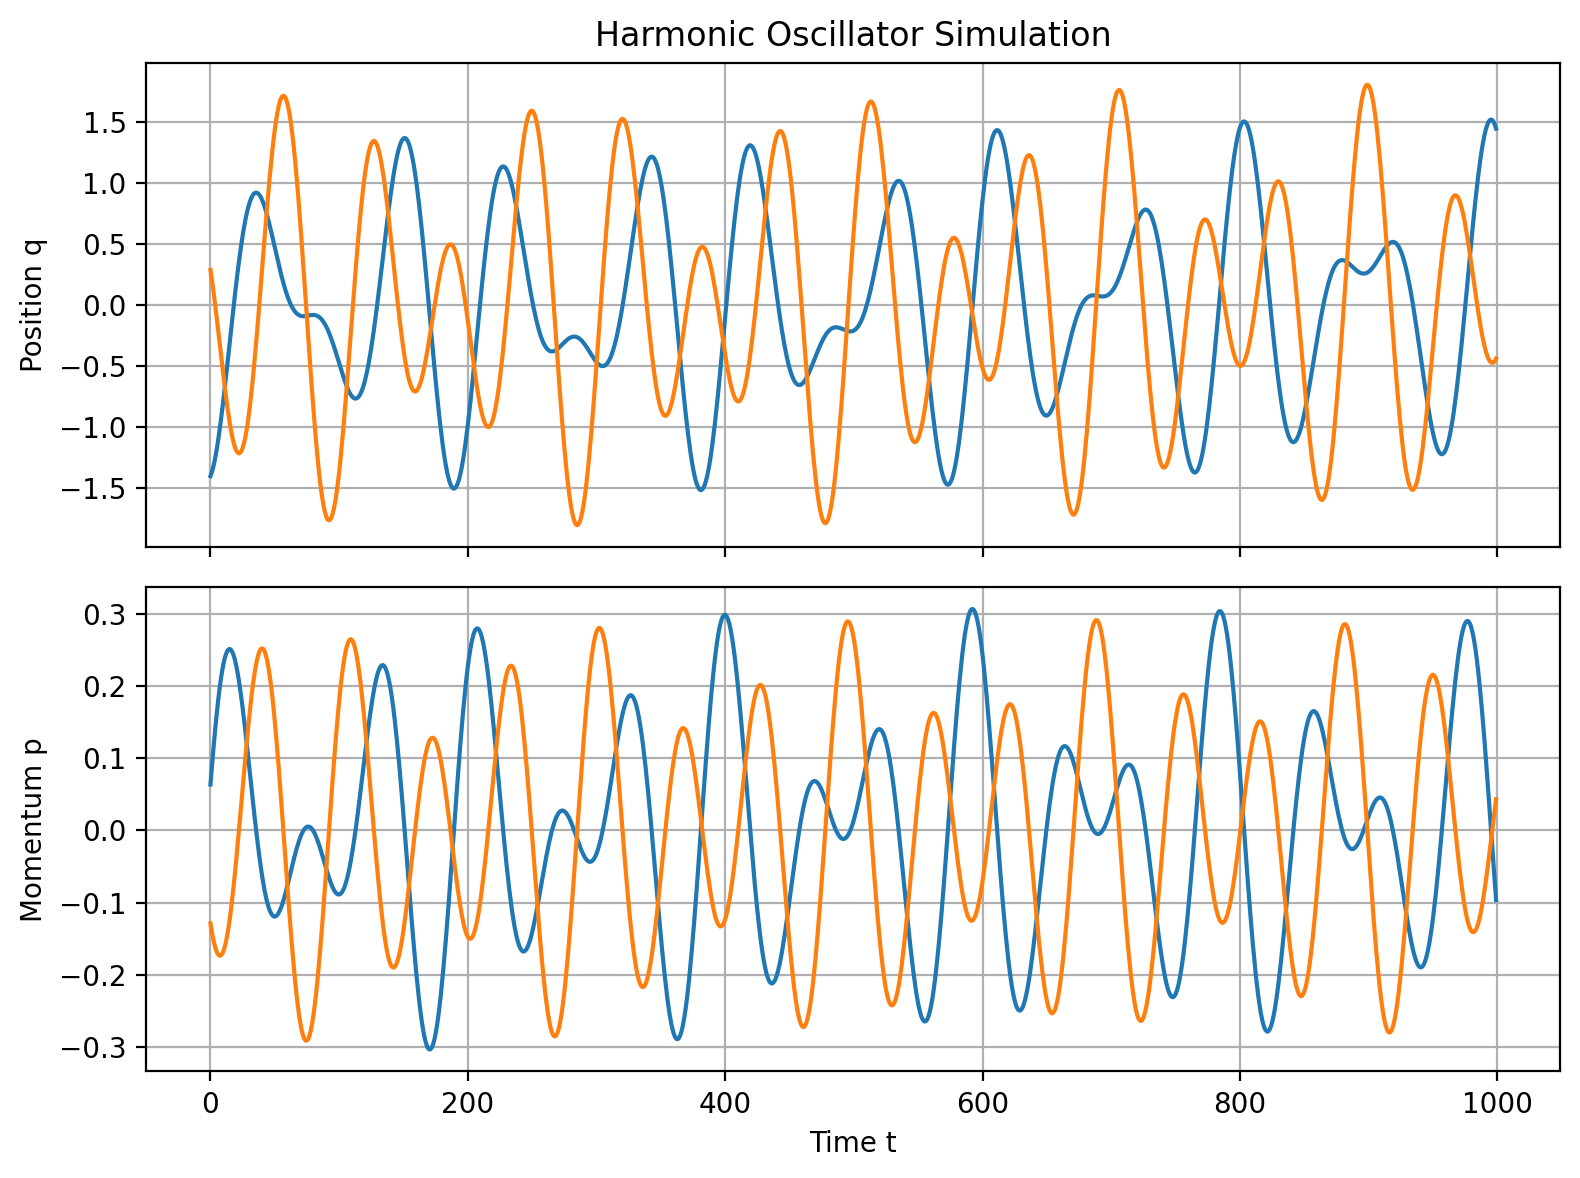

In [7]:
from matplotlib import pyplot as plt

# plot q and p
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t, q)
ax[0].set_ylabel('Position q')
ax[0].set_title('Harmonic Oscillator Simulation')
ax[0].grid()
ax[1].plot(t, p)
ax[1].set_ylabel('Momentum p')
ax[1].set_xlabel('Time t')
ax[1].grid()
plt.tight_layout()
plt.show()

In [8]:
# t, q, p は前セルのシミュレーション出力。q, p の shape は (T, n)
T, n = q.shape
assert p.shape == (T, n)
dt = float(t[1] - t[0])

# 時系列で分割（情報漏洩を防ぐため、時間で切る）
frac_train = 0.1
frac_test  = 0.5
T_train = int(T * frac_train)
T_test  = int(T * frac_test)

q_train = jnp.asarray(q[:T_train])
p_train = jnp.asarray(p[:T_train])

q_test  = jnp.asarray(q[-T_test:])
p_test  = jnp.asarray(p[-T_test:])


## HNN

$$
\frac{\partial H_{\phi, \psi}}{\partial q} = \frac{\partial h_\psi}{\partial I} \frac{\partial I_\phi}{\partial q}, \quad
\frac{\partial H_{\phi, \psi}}{\partial p} = \frac{\partial h_\psi}{\partial I} \frac{\partial I_\phi}{\partial p}. 
$$
ここで
\begin{equation*}
(I_x, I_y) = \psi_{2K+1} \circ \psi_{2K} \circ \cdots \circ \psi_{0} (q,p)
\end{equation*}
where
\begin{equation*}
\psi_{2k} (q,p) = (q, p+f_{2k} (q)), \quad \psi_{2k+1} (q,p) = (q+f_{2k+1}(p),p).
\end{equation*}

よって
\begin{align}
\frac{\partial I_x}{\partial q} = \partial 
\end{align}

In [ ]:
model = MyActionAngleNetwork(
    dim_config=n,
    dim_hidden_list=[100, 400, 100],
    num_gsblocks=20,
    type_polar="canonical",
    activation=nn.silu,
    mlp_res_connection=False,
    theta_predictor="gradient",
)


In [10]:
# Initialize model and count total parameters
import jax, jax.numpy as jnp

rng = jax.random.PRNGKey(0)
q0 = jnp.zeros((1, int(n)))
p0 = jnp.zeros((1, int(n)))
delta_t0 = jnp.asarray(0.1)

variables = model.init(rng, q0, p0, delta_t0)
params = variables['params']
num_params = sum(jax.tree_util.tree_leaves(jax.tree_util.tree_map(lambda x: x.size, params)))
print(f'Total parameters: {num_params}')


Total parameters: 7441


In [11]:
# import findiff
# n_traj_findiff = 5
# j = 1
# findiff.coefficients(deriv=1, offsets=[i-j for i in range(n_traj_findiff)])['coefficients']

In [12]:

# n_traj_findiff = 10
# # esimated velocities with the finite difference method
# fd_coef=[jnp.array(findiff.coefficients(deriv=1, offsets=[i-j for i in range(n_traj_findiff)])['coefficients']) \
#                  for j in range(n_traj_findiff)] #coefficients for the finite difference method
# #veloc_esti = jnp.hstack([jnp.sum(X_traj*fd_coef[i].reshape(-1,1), axis=1)/Ts for i in range(n_traj_findiff)]) 
# print(fd_coef[0])

Oct 7th 実装アドバイス
+ leapfrog法でできるかも (by本武さん)
+ HNN: dq/dt, dp/dtが与えられている場合が多い (by後藤さん)
+ 解析的にdq/dt, dp/dtが a) わかっている状況、b) わからない状況 でいずれもやってみる
+ a) Hamiltonianが与えられていて、保存量がわからない場合などは潜在空間でのhamiltonianの値をexactに与えられる

In [13]:
# --- New helper: batched ∂H/∂q, ∂H/∂p ---
def H_gt_grad_batch(q: jnp.ndarray, p: jnp.ndarray, gt_params):
    """
    q, p: (B, n) -> dHdq, dHdp each (B, n)
    """
    def Hsum(q, p):
        return harmonic_hamiltonian_jax(q, p, gt_params).sum()

    dHdq, dHdp = jax.grad(Hsum, argnums=(0, 1))(q, p)
    return dHdq, dHdp


def train_step(params, opt_state, x, y, delta_t, alpha, beta, *, apply_fn, tx, gt_params):
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, n), (B, n)

    dHdq_gt, dHdp_gt = H_gt_grad_batch(q, p, gt_params)

    # def H_hat_single(pp, qi, pi):
    #     return apply_fn({'params': pp}, qi[None, :], pi[None, :],
    #                     method=model.hamiltonian).squeeze()

    # grad_q_H_hat_single = jax.grad(H_hat_single, argnums=1)
    # grad_p_H_hat_single = jax.grad(H_hat_single, argnums=2)
    # dHdq_model = jax.vmap(lambda qi, pi: grad_q_H_hat_single(params, qi, pi))(q, p)
    # dHdp_model = jax.vmap(lambda qi, pi: grad_p_H_hat_single(params, qi, pi))(q, p)

    def loss_fn(pp):
        q_, p_, I, _ = apply_fn({'params': pp}, q, p, delta_t, train=True)

        loss_q_se = ((q_ - y[:, :n]) ** 2).mean()
        loss_p_se = ((p_ - y[:, n:]) ** 2).mean()

        def H_hat_single(qi, pi):
            return apply_fn({'params': pp}, qi[None, :], pi[None, :],
                            method=model.hamiltonian).squeeze()

        dHdq_model = jax.vmap(lambda qi, pi: jax.grad(H_hat_single, argnums=0)(qi, pi))(q, p)
        dHdp_model = jax.vmap(lambda qi, pi: jax.grad(H_hat_single, argnums=1)(qi, pi))(q, p)

        L_HNN = ((dHdq_model - dHdq_gt) ** 2).mean() + ((dHdp_model - dHdp_gt) ** 2).mean()

        loss_action = jnp.var(I, axis=0).sum()

        return loss_q_se + loss_p_se + alpha * loss_action + beta * L_HNN

    loss, grads = value_and_grad(loss_fn)(params)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


train_step_jit = jax.jit(train_step, static_argnames=('apply_fn', 'tx'))


In [14]:
@partial(jax.jit, static_argnames=('apply_fn',))
def eval_batch(params, x, y, delta_t, *, apply_fn):
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]

    q_, p_, _, _ = apply_fn({'params': params}, q, p, delta_t, train=False)

    loss_q_mse = ((q_ - y[:, :n]) ** 2).mean()
    loss_p_mse = ((p_ - y[:, n:]) ** 2).mean()

    return loss_q_mse + loss_p_mse


In [15]:
# --- Replace: 学習ループの該当部分 ---
seed = 201
lr = 1e-3
num_steps = 5000
batch_size = 100
log_every = 100
alpha = 1.0   # action loss weight
beta = 1.0
delta_t = dt  # base time step
delta_t_max = 10.0  # max jump multiplier during training
test_time_jumps = [1, 5, 10, 20, 50]  # time jumps to evaluate during testing


key = jax.random.PRNGKey(seed)
variables = model.init(key, jnp.zeros((1, n)), jnp.zeros((1, n)), jnp.asarray(dt))
nn_params = variables['params']

tx = optax.adam(learning_rate=lr)
opt_state = tx.init(nn_params)

for step in range(1, num_steps + 1):
    key, sub1, sub2 = jax.random.split(key, 3)
    max_jump = 1 + (step / num_steps) * (delta_t_max - 1)
    jump = jax.random.randint(sub1, shape=(), minval=1, maxval=int(max_jump) + 1)
    delta_t_scalar = jnp.asarray(delta_t * jump)

    curr_q, curr_p = q_train[:-jump], p_train[:-jump]
    tgt_q, tgt_p = q_train[jump:],  p_train[jump:]

    batch_size = min(batch_size, curr_q.shape[0])
    idx = jax.random.choice(sub2, curr_q.shape[0], shape=(batch_size,), replace=False)
    x = jnp.concatenate([curr_q[idx], curr_p[idx]], axis=-1)
    y = jnp.concatenate([tgt_q[idx], tgt_p[idx]], axis=-1)

    nn_params, opt_state, train_loss = train_step_jit(
        params=nn_params, opt_state=opt_state, x=x, y=y, delta_t=delta_t_scalar, alpha=alpha, beta=beta,
        apply_fn=model.apply, tx=tx, gt_params=gt_params_jax, 
    )

    if step % log_every == 0 or step == 1 or step == num_steps:
        test_losses = []
        for j in test_time_jumps:
            cq, cp = q_test[:-j], p_test[:-j]
            tq, tp = q_test[j:],  p_test[j:]
            loss = eval_batch(nn_params,
                              jnp.concatenate([cq, cp], axis=-1),
                              jnp.concatenate([tq, tp], axis=-1),
                              jnp.asarray(delta_t * j),
                              apply_fn=model.apply)
            test_losses.append(float(loss))
        print(f"step {step:5d} train {float(train_loss):.6f}  test " +
              ", ".join(f"jump={j}:{l:.6f}" for j, l in zip(test_time_jumps, test_losses)))


2025-10-24 12:23:19.903869: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:23:19.903903: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:23:19.903964: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:23:19.903975: W external/xla/xla/service/gpu/au

step     1 train 89389008.000000  test jump=1:508573.437500, jump=5:8901820.000000, jump=10:14733040.000000, jump=20:27036904.000000, jump=50:41798272.000000
step   100 train 270937.562500  test jump=1:603.854065, jump=5:13438.591797, jump=10:40290.113281, jump=20:76263.468750, jump=50:130893.296875
step   200 train 138275.921875  test jump=1:232.357819, jump=5:5206.485352, jump=10:16031.226562, jump=20:31110.246094, jump=50:53608.695312
step   300 train 83783.585938  test jump=1:113.613670, jump=5:2531.859863, jump=10:8074.755859, jump=20:16745.515625, jump=50:25011.914062
step   400 train 56476.964844  test jump=1:62.989349, jump=5:1389.368286, jump=10:4492.416992, jump=20:9868.755859, jump=50:16416.273438
step   500 train 40838.664062  test jump=1:38.328316, jump=5:872.136108, jump=10:2949.583008, jump=20:7221.231445, jump=50:11782.648438


2025-10-24 12:23:49.704767: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:23:49.704799: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:23:49.704859: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:23:49.704870: W external/xla/xla/service/gpu/au

step   600 train 31048.476562  test jump=1:22.860983, jump=5:528.340393, jump=10:1847.343262, jump=20:5034.370117, jump=50:8712.100586
step   700 train 24511.460938  test jump=1:14.144439, jump=5:333.747498, jump=10:1171.697144, jump=20:3396.769287, jump=50:6226.015625
step   800 train 19758.119141  test jump=1:13.960893, jump=5:328.972717, jump=10:1132.841919, jump=20:2978.325195, jump=50:5245.312500
step   900 train 16261.102539  test jump=1:11.360458, jump=5:270.793396, jump=10:956.518433, jump=20:2625.687012, jump=50:5873.521484
step  1000 train 13620.325195  test jump=1:8.557726, jump=5:204.127579, jump=10:734.230347, jump=20:2037.824707, jump=50:4818.100586
step  1100 train 11540.957031  test jump=1:5.516725, jump=5:133.321350, jump=10:496.622192, jump=20:1564.745605, jump=50:3695.078369


2025-10-24 12:24:13.115714: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:24:13.115744: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:24:13.115804: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:24:13.115815: W external/xla/xla/service/gpu/au

...

step  3400 train 1204.763306  test jump=1:0.497610, jump=5:10.949707, jump=10:40.870750, jump=20:143.982346, jump=50:474.398193
step  3500 train 1112.980591  test jump=1:0.489205, jump=5:10.851527, jump=10:39.796940, jump=20:139.234009, jump=50:450.736420
step  3600 train 1063.796753  test jump=1:0.479188, jump=5:10.821657, jump=10:38.505997, jump=20:131.766510, jump=50:408.743439
step  3700 train 1003.260010  test jump=1:0.467307, jump=5:10.886114, jump=10:37.825962, jump=20:128.266739, jump=50:407.011169
step  3800 train 915.497131  test jump=1:0.444715, jump=5:10.568140, jump=10:36.081909, jump=20:122.514221, jump=50:383.455200
step  3900 train 853.916931  test jump=1:0.414012, jump=5:9.981831, jump=10:33.670422, jump=20:114.099335, jump=50:364.718414


2025-10-24 12:26:13.997033: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:26:13.997066: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:26:13.997128: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:26:13.997140: W external/xla/xla/service/gpu/au

step  4000 train 809.925354  test jump=1:0.380309, jump=5:9.212866, jump=10:30.596975, jump=20:101.783401, jump=50:339.448669
step  4100 train 768.453674  test jump=1:0.342251, jump=5:8.288128, jump=10:27.213638, jump=20:89.127472, jump=50:307.243805
step  4200 train 704.185364  test jump=1:0.303268, jump=5:7.340860, jump=10:23.963833, jump=20:77.198380, jump=50:272.559723
step  4300 train 674.744385  test jump=1:0.265348, jump=5:6.376643, jump=10:20.901491, jump=20:66.909454, jump=50:238.327179
step  4400 train 597.965454  test jump=1:0.227142, jump=5:5.406752, jump=10:17.819481, jump=20:57.406212, jump=50:212.328552


2025-10-24 12:26:39.144207: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:26:39.144240: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:26:39.144301: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-24 12:26:39.144312: W external/xla/xla/service/gpu/au

step  4500 train 586.862244  test jump=1:0.193988, jump=5:4.579436, jump=10:15.333158, jump=20:48.910774, jump=50:188.086243
step  4600 train 513.615540  test jump=1:0.175786, jump=5:4.090675, jump=10:13.887791, jump=20:43.946022, jump=50:174.674225
step  4700 train 501.396423  test jump=1:0.171806, jump=5:3.958151, jump=10:13.628197, jump=20:42.964630, jump=50:172.536194
step  4800 train 476.016052  test jump=1:0.168090, jump=5:3.854583, jump=10:13.462084, jump=20:43.303169, jump=50:175.354233
step  4900 train 460.524597  test jump=1:0.163770, jump=5:3.728779, jump=10:13.013152, jump=20:42.686356, jump=50:172.694580
step  5000 train 417.018616  test jump=1:0.155686, jump=5:3.516164, jump=10:12.080021, jump=20:39.805210, jump=50:166.893372


In [16]:
# Roll out model predictions from initial state across full horizon

# Convert true series to JAX arrays
q_true = jnp.asarray(q_test)
p_true = jnp.asarray(p_test)
T_total = 100 #int(q_true.shape[0])
n_dim = int(q_true.shape[1])

# Initial state and per-step delta_t
q0_roll = q_true[:1].squeeze(axis=0) if q_true.ndim==2 else q_true[:1]
p0_roll = p_true[:1].squeeze(axis=0) if p_true.ndim==2 else p_true[:1]
delta_t_infer = jnp.asarray(float(dt))

def _step_fn(carry, _):
    q_curr, p_curr = carry
    q_next, p_next, _, _ = model.apply({'params': nn_params}, q_curr, p_curr, delta_t_infer, train=False)
    return (q_next, p_next), (q_next, p_next)

# Rollout T_total-1 steps to get length T_total with the initial appended
(_, _), (qs_seq, ps_seq) = jax.lax.scan(_step_fn, (q0_roll, p0_roll), None, length=max(T_total-1, 0))
q_pred = jnp.concatenate([q0_roll[None,...], qs_seq], axis=0) if T_total>0 else q0_roll
p_pred = jnp.concatenate([p0_roll[None,...], ps_seq], axis=0) if T_total>0 else p0_roll

# Remove batch axis
q_pred = jnp.squeeze(q_pred, axis=1) if q_pred.ndim==3 else q_pred
p_pred = jnp.squeeze(p_pred, axis=1) if p_pred.ndim==3 else p_pred

print('q_pred shape:', q_pred.shape, 'p_pred shape:', p_pred.shape)


q_pred shape: (100, 2) p_pred shape: (100, 2)


In [17]:
t.shape

(1000,)

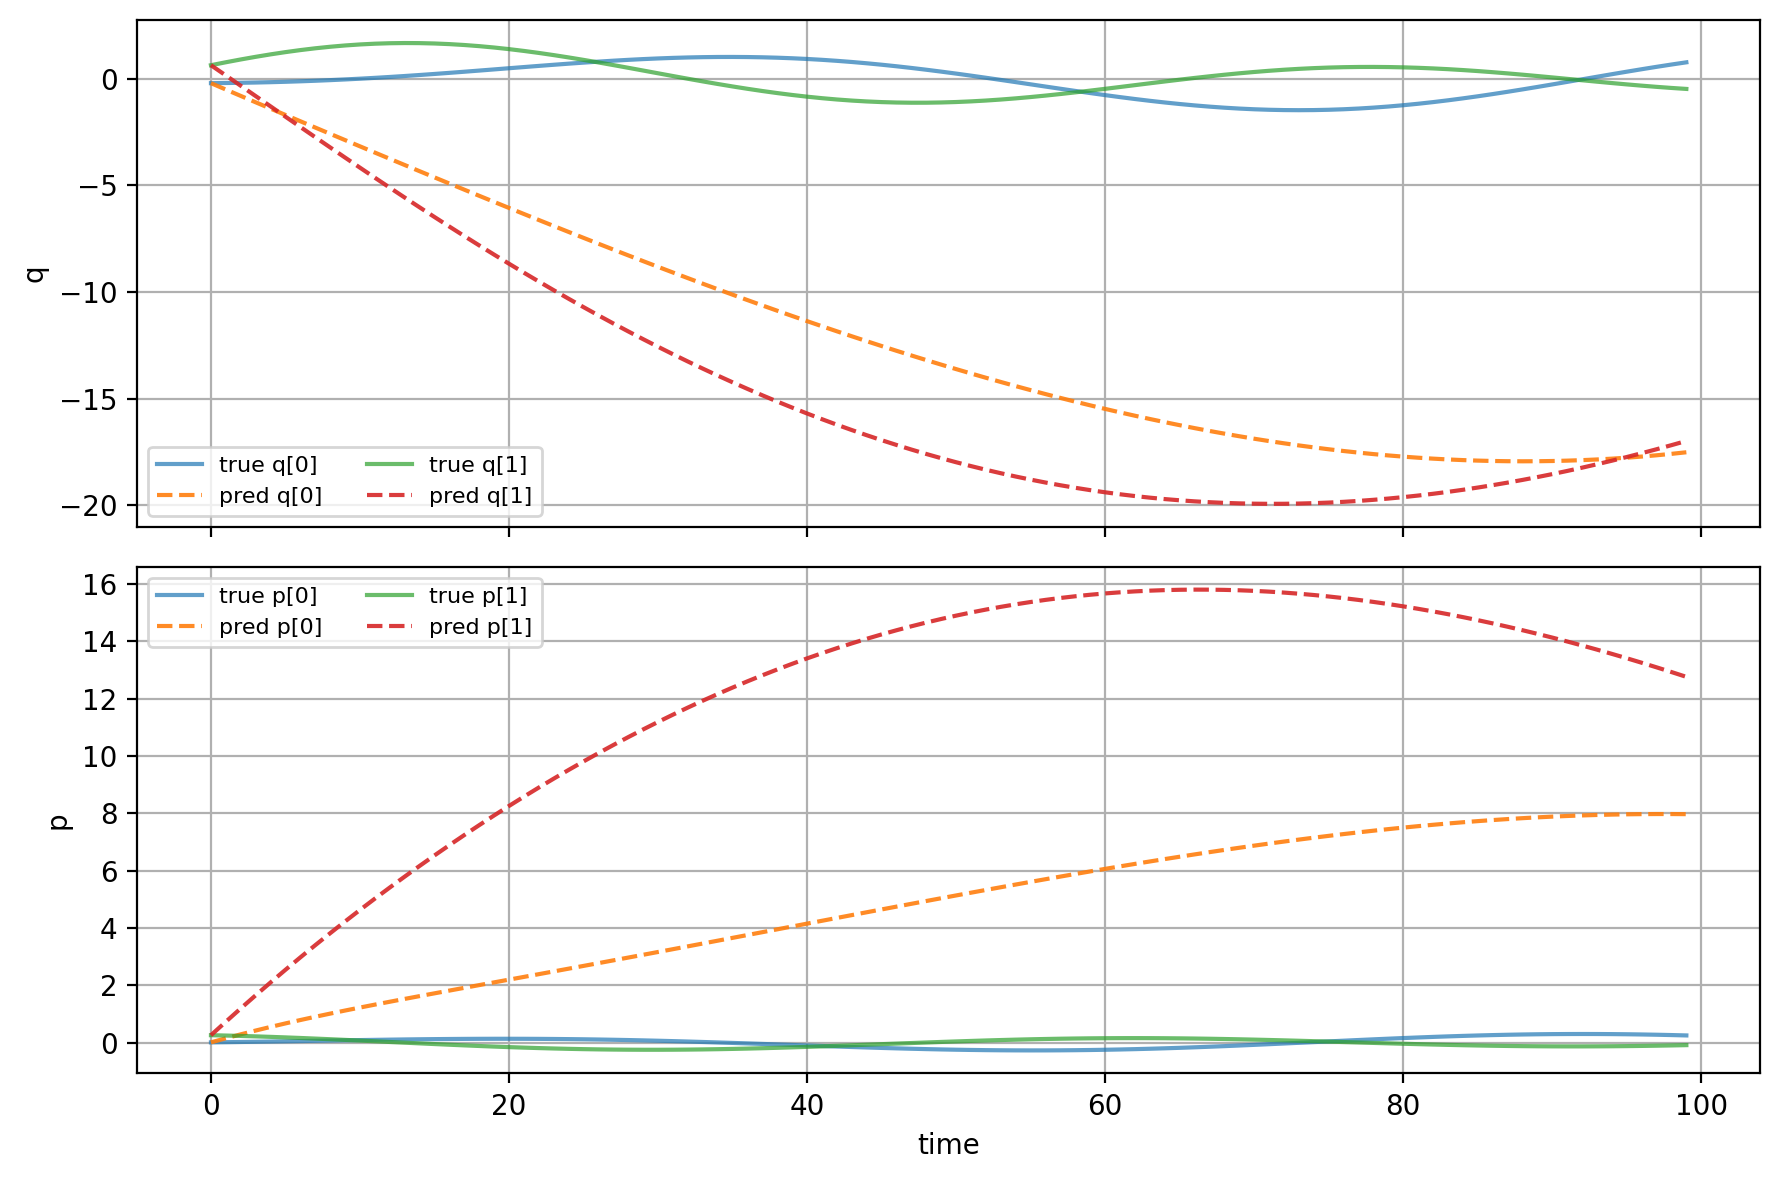

In [18]:
# Plot true vs predicted trajectories
import matplotlib.pyplot as plt
t_arr = np.asarray(t[:T_total])
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Positions
for i in range(q_pred.shape[1]):
    axes[0].plot(t_arr, np.asarray(q_true)[:T_total, i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, np.asarray(q_pred)[:, i], '--', label=f'pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

# Momenta
for i in range(p_pred.shape[1]):
    axes[1].plot(t_arr, np.asarray(p_true)[:T_total, i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, np.asarray(p_pred)[:, i], '--', label=f'pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


# Beta = 0 (No HHN)

In [19]:
# --- Replace: 学習ループの該当部分 ---
seed = 201
lr = 1e-3
num_steps = 5000
batch_size = 100
log_every = 100
alpha = 1.0   # action loss weight
beta = 0.0
delta_t = dt  # base time step
delta_t_max = 10.0  # max jump multiplier during training
test_time_jumps = [1, 5, 10, 20, 50]  # time jumps to evaluate during testing


key = jax.random.PRNGKey(seed)
variables = model.init(key, jnp.zeros((1, n)), jnp.zeros((1, n)), jnp.asarray(dt))
nn_params = variables['params']

tx = optax.adam(learning_rate=lr)
opt_state = tx.init(nn_params)

for step in range(1, num_steps + 1):
    key, sub1, sub2 = jax.random.split(key, 3)
    max_jump = 1 + (step / num_steps) * (delta_t_max - 1)
    jump = jax.random.randint(sub1, shape=(), minval=1, maxval=int(max_jump) + 1)
    delta_t_scalar = jnp.asarray(delta_t * jump)

    curr_q, curr_p = q_train[:-jump], p_train[:-jump]
    tgt_q, tgt_p = q_train[jump:],  p_train[jump:]

    batch_size = min(batch_size, curr_q.shape[0])
    idx = jax.random.choice(sub2, curr_q.shape[0], shape=(batch_size,), replace=False)
    x = jnp.concatenate([curr_q[idx], curr_p[idx]], axis=-1)
    y = jnp.concatenate([tgt_q[idx], tgt_p[idx]], axis=-1)

    nn_params, opt_state, train_loss = train_step_jit(
        params=nn_params, opt_state=opt_state, x=x, y=y, delta_t=delta_t_scalar, alpha=alpha, beta=beta,
        apply_fn=model.apply, tx=tx, gt_params=gt_params_jax, 
    )

    if step % log_every == 0 or step == 1 or step == num_steps:
        test_losses = []
        for j in test_time_jumps:
            cq, cp = q_test[:-j], p_test[:-j]
            tq, tp = q_test[j:],  p_test[j:]
            loss = eval_batch(nn_params,
                              jnp.concatenate([cq, cp], axis=-1),
                              jnp.concatenate([tq, tp], axis=-1),
                              jnp.asarray(delta_t * j),
                              apply_fn=model.apply)
            test_losses.append(float(loss))
        print(f"step {step:5d} train {float(train_loss):.6f}  test " +
              ", ".join(f"jump={j}:{l:.6f}" for j, l in zip(test_time_jumps, test_losses)))


step     1 train 88616824.000000  test jump=1:502199.437500, jump=5:8928675.000000, jump=10:14693660.000000, jump=20:26173908.000000, jump=50:36091896.000000
step   100 train 246810.796875  test jump=1:242.939728, jump=5:5841.365234, jump=10:20065.437500, jump=20:49584.226562, jump=50:105528.250000
step   200 train 124003.195312  test jump=1:76.204620, jump=5:1852.427490, jump=10:6830.619141, jump=20:20697.654297, jump=50:54241.867188
step   300 train 73510.867188  test jump=1:56.784431, jump=5:1334.939941, jump=10:4737.722656, jump=20:13068.279297, jump=50:30747.105469
step   400 train 48442.675781  test jump=1:40.298515, jump=5:928.957703, jump=10:3189.721924, jump=20:8503.498047, jump=50:20202.951172
step   500 train 34170.472656  test jump=1:21.972076, jump=5:524.890747, jump=10:1845.279297, jump=20:5267.732422, jump=50:14359.527344
step   600 train 25432.378906  test jump=1:14.049820, jump=5:334.731384, jump=10:1211.813354, jump=20:3608.410645, jump=50:11024.224609
step   700 trai

In [20]:
# Roll out model predictions from initial state across full horizon

# Convert true series to JAX arrays
q_true = jnp.asarray(q_test)
p_true = jnp.asarray(p_test)
T_total = 100 #int(q_true.shape[0])
n_dim = int(q_true.shape[1])

# Initial state and per-step delta_t
q0_roll = q_true[:1].squeeze(axis=0) if q_true.ndim==2 else q_true[:1]
p0_roll = p_true[:1].squeeze(axis=0) if p_true.ndim==2 else p_true[:1]
delta_t_infer = jnp.asarray(float(dt))

def _step_fn(carry, _):
    q_curr, p_curr = carry
    q_next, p_next, _, _ = model.apply({'params': params}, q_curr, p_curr, delta_t_infer, train=False)
    return (q_next, p_next), (q_next, p_next)

# Rollout T_total-1 steps to get length T_total with the initial appended
(_, _), (qs_seq, ps_seq) = jax.lax.scan(_step_fn, (q0_roll, p0_roll), None, length=max(T_total-1, 0))
q_pred = jnp.concatenate([q0_roll[None,...], qs_seq], axis=0) if T_total>0 else q0_roll
p_pred = jnp.concatenate([p0_roll[None,...], ps_seq], axis=0) if T_total>0 else p0_roll

# Remove batch axis
q_pred = jnp.squeeze(q_pred, axis=1) if q_pred.ndim==3 else q_pred
p_pred = jnp.squeeze(p_pred, axis=1) if p_pred.ndim==3 else p_pred

print('q_pred shape:', q_pred.shape, 'p_pred shape:', p_pred.shape)


q_pred shape: (100, 2) p_pred shape: (100, 2)


In [21]:
t.shape

(1000,)

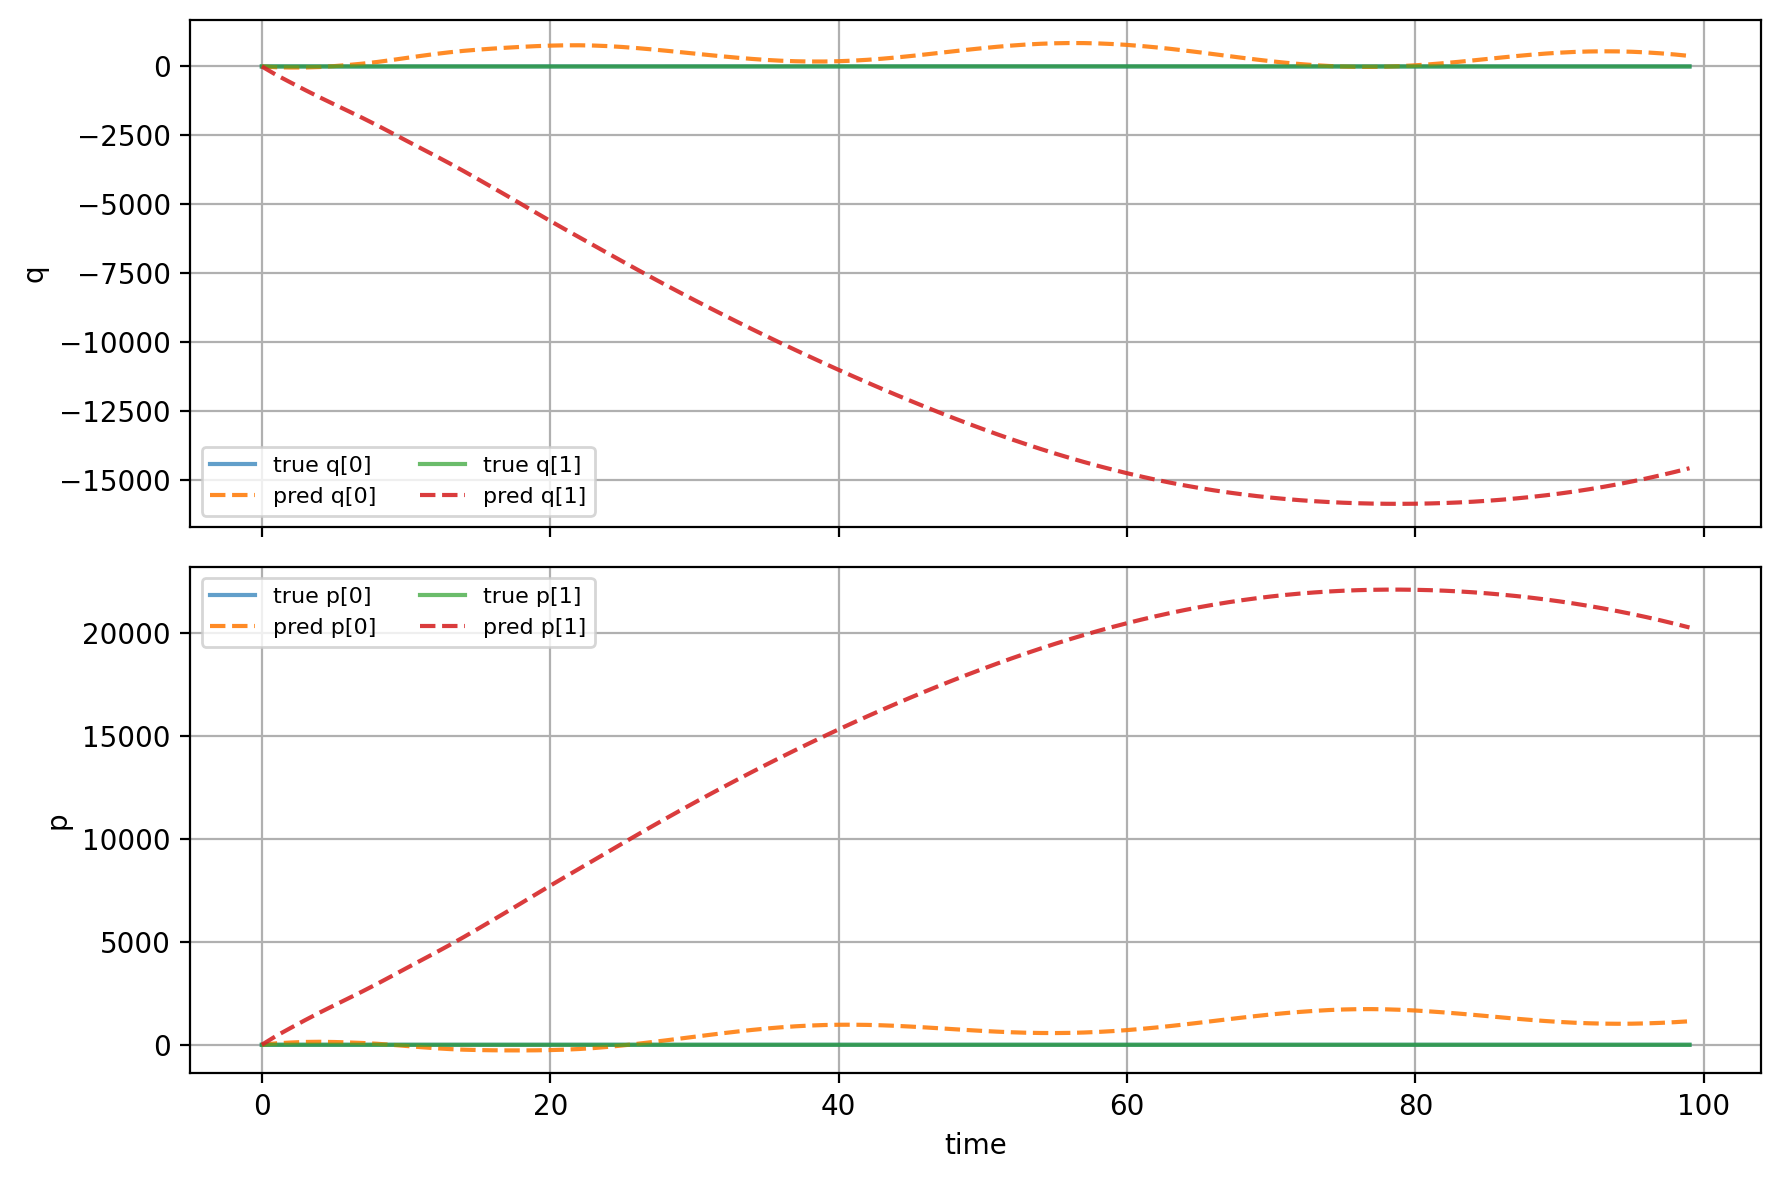

In [22]:
# Plot true vs predicted trajectories
import matplotlib.pyplot as plt
t_arr = np.asarray(t[:T_total])
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Positions
for i in range(q_pred.shape[1]):
    axes[0].plot(t_arr, np.asarray(q)[range(T_total), i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, np.asarray(q_pred)[:, i], '--', label=f'pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

# Momenta
for i in range(p_pred.shape[1]):
    axes[1].plot(t_arr, np.asarray(p)[range(T_total), i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, np.asarray(p_pred)[:, i], '--', label=f'pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Plot true vs predicted trajectories
import matplotlib.pyplot as plt
t_arr = np.asarray(t[:q_pred.shape[0]])  # Ensure t_arr matches the length of q_pred
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Positions
for i in range(q_pred.shape[1]):
    axes[0].plot(t_arr, np.asarray(q)[:q_pred.shape[0], i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, np.asarray(q_pred)[:, i], '--', label=f'pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

# Momenta
for i in range(p_pred.shape[1]):
    axes[1].plot(t_arr, np.asarray(p)[:p_pred.shape[0], i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, np.asarray(p_pred)[:, i], '--', label=f'pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# # オプティマイザ
# tx = optax.adam(learning_rate=lr)
# opt_state = tx.init(params)

# print("Starting training...")
# print(f"num_steps: {num_steps}, delta_t_max: {delta_t_max}, batch_size: {batch_size}, log_every: {log_every}")
# print(f"test_time_jumps: {test_time_jumps}")
# print(f"alpha (weight for action constancy loss): {alpha}")

# for step in range(1, num_steps + 1):
#     key, sub1, sub2 = jax.random.split(key, 3)

#     # jump幅をサンプル
#     max_time_jump_for_step = 1 + (step / num_steps) * (delta_t_max - 1)
#     jump = jax.random.randint(sub1, shape=(), minval=1, maxval=int(max_time_jump_for_step) + 1)
#     delta_t_scalar = jnp.asarray(delta_t * jump)

#     # n_train - jump このペアを作る
#     curr_q, curr_p = q_train[:-jump], p_train[:-jump]
#     tgt_q, tgt_p = q_train[jump:], p_train[jump:]

#     # 重複を許さないでbatch_size個くらいサンプル
#     batch_size = min(batch_size, curr_q.shape[0]) # curr_qの数がとても小さいときはそれを上限にする
#     idx_sample = jax.random.choice(
#         sub2, curr_q.shape[0], shape=(batch_size,), replace=False
#     )
#     batch = (
#         curr_q[idx_sample], curr_p[idx_sample],
#         tgt_q[idx_sample], tgt_p[idx_sample],
#     )

#     #batch = sample_train_batch(sub)
#     # batch = train_curr_q[idx], train_curr_p[idx], train_tgt_q[idx],  train_tgt_p[idx],

#     params, opt_state, train_loss = train_step_jit(
#         params=params,
#         opt_state=opt_state,
#         x=jnp.concatenate([batch[0], batch[1]], axis=-1),
#         y=jnp.concatenate([batch[2], batch[3]], axis=-1),
#         alpha=alpha,
#         delta_t=delta_t_scalar,
#         apply_fn=model.apply,
#         tx=tx,
#     )

#     if not no_wandb:
#         wandb.log({
#             'train/loss': float(train_loss),
#             'train/step': step,
#             'train/delta_t': float(delta_t_scalar),
#         }, step=step)

#     if step % log_every == 0 or step == 1 or step == num_steps:

#         test_loss_list = []
#         for jump in test_time_jumps:
#             test_curr_q, test_curr_p = q_test[:-jump], p_test[:-jump] # (T-jump, n)
#             test_tgt_q, test_tgt_p = q_test[jump:], p_test[jump:] # (T-jump, n)
#             delta_t_test = delta_t * jump
#             test_loss_jump = eval_batch_jit(
#                 params=params,
#                 x=jnp.concatenate([test_curr_q, test_curr_p], axis=-1), 
#                 y=jnp.concatenate([test_tgt_q, test_tgt_p], axis=-1),
#                 delta_t=delta_t_test,
#                 apply_fn=model.apply,
#             )
#             test_loss_list.append(test_loss_jump)
        
#         test_str = ", ".join(f"jump={j}: {float(l):.6f}"
#                             for j, l in zip(test_time_jumps, test_loss_list))
#         print(f"step {step:5d}  train_loss {float(train_loss):.6f}  test_loss [{test_str}]")


#         if not no_wandb:
#             for j, l in zip(test_time_jumps, test_loss_list):
#                 wandb.log({
#                     f'test/loss_jump_{j}': float(l),
#                     'train/step': step,
#                 }, step=step)


#     save_dir = Path(save_dir) / f"{experiment_name}_job{job_id}"
#     if step % save_every == 0 or step == num_steps:
#         # 定期的にモデルを保存
#         _atomic_save(save_dir / 'checkpoints' / f'params_step_{step:05d}.params', params)
#         print(f"[ckpt] saved: {save_dir / 'checkpoints' / f'params_step_{step:05d}.params'}")


# if not no_wandb:
#     wandb.log({
#         "final/train_loss": float(train_loss),
#         "final/step": step,
#     }, step=step)
#     for j, l in zip(test_time_jumps, test_loss_list):
#         wandb.log({
#             f'final/test_loss_jump_{j}': float(l),
#         }, step=step)

# print("Training completed.")
# if not no_wandb:
#     wandb.finish()


NameError: name 'args' is not defined

In [ ]:

# rng = jax.random.PRNGKey(0)
# params = model.init(rng, jnp.array([[0.0,0.0]]), jnp.array([[0.0,0.0]]), jnp.asarray(0.1))["params"]

# # オプティマイザ
# tx = optax.adam(1e-3)
# opt_state = tx.init(params)
# num_steps = 5000
# delta_t_max = 10 # maximum jump (see Eq.(10) in the paper)

# batch_size = 100
# log_every = 100
# test_time_jumps = [1,2,5,10,20,50]
# alpha = 1 #0.5  # weight for action constancy loss

# normalize_qp = True

# print("Start training...")
# print(f"num_steps: {num_steps}, delta_t_max: {delta_t_max}, batch_size: {batch_size}, log_every: {log_every}")
# print(f"test_time_jumps: {test_time_jumps}")
# print(f"alpha (weight for action constancy loss): {alpha}")


# for step in range(1, num_steps + 1):
#     rng, sub1, sub2, sub3 = jax.random.split(rng, 4)

#     # jump幅をサンプル
#     max_time_jump_for_step = 1 + (step / num_steps) * (delta_t_max - 1)
#     jump = jax.random.randint(sub1, shape=(), minval=1, maxval=max_time_jump_for_step + 1)
#     # jump_max = jax.random.randint(sub1, shape=(), minval=1, maxval=int( step/num_steps * delta_t_max ) + 1 )
#     # jump = jax.random.randint(sub2, shape=(), minval=1, maxval=jump_max+1)
#     # jumpはあくまでステップ幅であり実時間ではない、実時間を計算
#     delta_t_scalar = jnp.asarray(dt * jump)

#     # n_train - jump このペアを作る
#     curr_q, curr_p = q_train[:-jump], p_train[:-jump]
#     tgt_q, tgt_p = q_train[jump:], p_train[jump:]

#     # 重複を許してbatch_size個サンプル
#     batch_size = min(batch_size, curr_q.shape[0]) # curr_qの数がとても小さいときはそれを上限にする
#     idx_sample = jax.random.choice(
#         sub3, curr_q.shape[0], shape=(batch_size,), replace=False
#     )
#     batch = (
#         curr_q[idx_sample], curr_p[idx_sample],
#         tgt_q[idx_sample], tgt_p[idx_sample],
#     )

#     #batch = sample_train_batch(sub)
#     # batch = train_curr_q[idx], train_curr_p[idx], train_tgt_q[idx],  train_tgt_p[idx],

#     params, opt_state, train_loss = train_step(
#         params=params,
#         opt_state=opt_state,
#         x=jnp.concatenate([batch[0], batch[1]], axis=-1),
#         y=jnp.concatenate([batch[2], batch[3]], axis=-1),
#         alpha=alpha,
#         delta_t=delta_t_scalar,
#         key=rng
#     )

#     if step % log_every == 0 or step == 1:

#         test_loss_list = []
#         for jump in test_time_jumps:
#             test_curr_q, test_curr_p = q_test[:-jump], p_test[:-jump] # (T-jump, n)
#             test_tgt_q, test_tgt_p = q_test[jump:], p_test[jump:] # (T-jump, n)
#             delta_t_test = dt * jump
#             test_loss_jump = eval_batch(
#                 params=params,
#                 x=jnp.concatenate([test_curr_q, test_curr_p], axis=-1), 
#                 y=jnp.concatenate([test_tgt_q, test_tgt_p], axis=-1),
#                 delta_t=delta_t_test,
#                 key=eval_key
#             )
#             test_loss_list.append(test_loss_jump)
        
#         test_str = ", ".join(f"jump={j}: {float(l):.6f}"
#                             for j, l in zip(test_time_jumps, test_loss_list))
#         print(f"step {step:5d}  train_loss {float(train_loss):.6f}  test_loss [{test_str}]")

#         # print(f"step {step:5d}  train_loss {float(train_loss):.6f}  test_loss {float(test_loss_list):.6f}")
#         # wandb.log({
#         #     "train/loss": float(train_loss),
#         #     "test/loss": float(test_loss),
#         #     "step": step,
#         # })



#         # for jump in test_time_jumps:
#         #     test_curr_q.append( q_test[:-jump] )
#         #     test_curr_p.append( p_test[:-jump] )
#         #     test_tgt_q.append( q_test[jump:] )
#         #     test_tgt_p.append( p_test[jump:] )
#         #     delta_t_test.append(jnp.repeat(dt * jump, q_test.shape[0]-jump))
#         # test_curr_q = jnp.concatenate(test_curr_q, axis=0)
#         # test_curr_p = jnp.concatenate(test_curr_p, axis=0)
#         # test_tgt_q  = jnp.concatenate(test_tgt_q, axis=0)
#         # test_tgt_p  = jnp.concatenate(test_tgt_p, axis=0)
#         # delta_t_test = jnp.concatenate(delta_t_test, axis=0)

        
#         # test_loss = eval_batch(
#         #     params=params,
#         #     x=jnp.concatenate([test_curr_q, test_curr_p], axis=-1), 
#         #     y=jnp.concatenate([test_tgt_q, test_tgt_p], axis=-1),
#         #     delta_t=delta_t_test,
#         #     key=eval_key
#         # )
        

Start training...
num_steps: 5000, delta_t_max: 10, batch_size: 100, log_every: 100
test_time_jumps: [1, 2, 5, 10, 20, 50]
alpha (weight for action constancy loss): 1


TypeError: train_step() got an unexpected keyword argument 'key'